# Credit Scoring Model

### CodeAlpha Machine Learning Internship

#### Task 1: Credit Scoring Model

**Developed by:** Anshika Vats
---
**Objective**
Predict whether an applicant is creditworthy based on financial and personal information using Machine Learning classification algorithms.

**Algorithms Used**
- Logistic Regression
- Decision Tree
- Random Forest

**Evaluation Metrics**
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

#Import Libraries

In [4]:
import os

os.listdir('/content')

['.config', 'statlog+german+credit+data.zip', 'sample_data']

#Unzip the dataset

In [5]:
!unzip "/content/statlog+german+credit+data.zip"

Archive:  /content/statlog+german+credit+data.zip
  inflating: german.data             
  inflating: german.data-numeric     
  inflating: german.doc              
  inflating: Index                   


In [6]:
!ls

german.data	     german.doc  sample_data
german.data-numeric  Index	 statlog+german+credit+data.zip


# Load the Dataset

The German Credit Dataset from the UCI Machine Learning Repository is used in this project. It contains customer financial information and a target variable indicating whether the customer has good or bad credit risk.

In [7]:
import pandas as pd

column_names = [
    "Checking_Account",
    "Duration",
    "Credit_History",
    "Purpose",
    "Credit_Amount",
    "Savings_Account",
    "Employment",
    "Installment_Rate",
    "Personal_Status_Sex",
    "Other_Debtors",
    "Residence_Since",
    "Property",
    "Age",
    "Other_Installment_Plans",
    "Housing",
    "Existing_Credits",
    "Job",
    "Dependents",
    "Telephone",
    "Foreign_Worker",
    "Risk"
]

In [8]:
df = pd.read_csv(
    "/content/german.data",
    sep=" ",
    header=None,
    names=column_names
)

## Dataset Overview

Before building machine learning models, it is important to understand the structure of the dataset. This includes checking the dimensions, data types, missing values, and basic statistical information.

In [9]:
df.head()

,Checking_Account,Duration,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Dependents,Telephone,Foreign_Worker,Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [10]:
df.shape

(1000, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Checking_Account         1000 non-null   object
 1   Duration                 1000 non-null   int64 
 2   Credit_History           1000 non-null   object
 3   Purpose                  1000 non-null   object
 4   Credit_Amount            1000 non-null   int64 
 5   Savings_Account          1000 non-null   object
 6   Employment               1000 non-null   object
 7   Installment_Rate         1000 non-null   int64 
 8   Personal_Status_Sex      1000 non-null   object
 9   Other_Debtors            1000 non-null   object
 10  Residence_Since          1000 non-null   int64 
 11  Property                 1000 non-null   object
 12  Age                      1000 non-null   int64 
 13  Other_Installment_Plans  1000 non-null   object
 14  Housing                  1000 non-null   

# Missing Value Analysis

Missing values can negatively affect machine learning models. Therefore, we check whether the dataset contains any missing values before proceeding with preprocessing.

In [12]:
df.isnull().sum()

,0
Checking_Account,0
Duration,0
Credit_History,0
Purpose,0
Credit_Amount,0
Savings_Account,0
Employment,0
Installment_Rate,0
Personal_Status_Sex,0
Other_Debtors,0


# Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand the distribution of features and the target variable before preprocessing and model building.

In [13]:
df["Risk"].value_counts()

,count
Risk,
1,700
2,300


In [14]:
(df["Risk"].value_counts(normalize=True) * 100).round(2)

,proportion
Risk,
1,70.0
2,30.0


In [15]:
import matplotlib.pyplot as plt

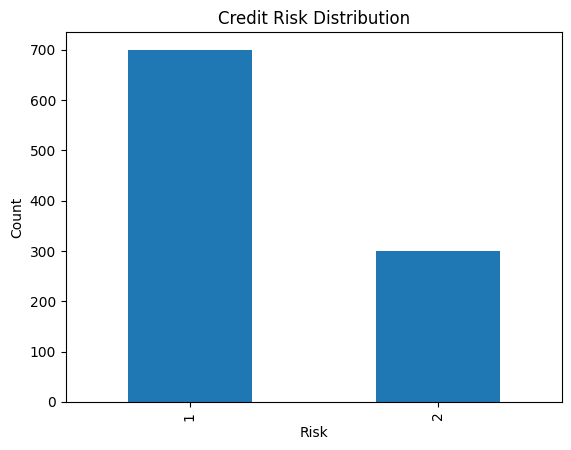

In [16]:
df["Risk"].value_counts().plot(kind="bar")

plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")

plt.show()

In [17]:
df.describe()

,Duration,Credit_Amount,Installment_Rate,Residence_Since,Age,Existing_Credits,Dependents,Risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


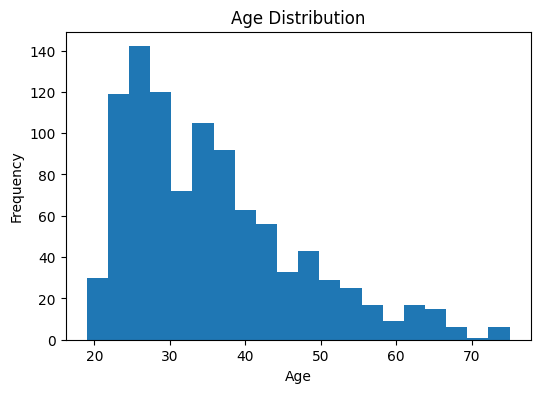

In [18]:
plt.figure(figsize=(6,4))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

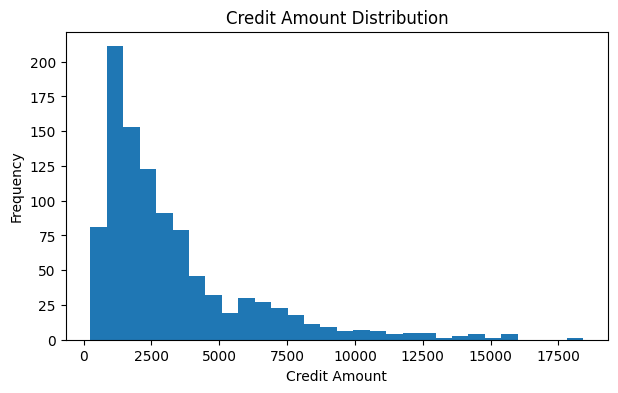

In [19]:
plt.figure(figsize=(7,4))

plt.hist(df["Credit_Amount"], bins=30)

plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")

plt.show()

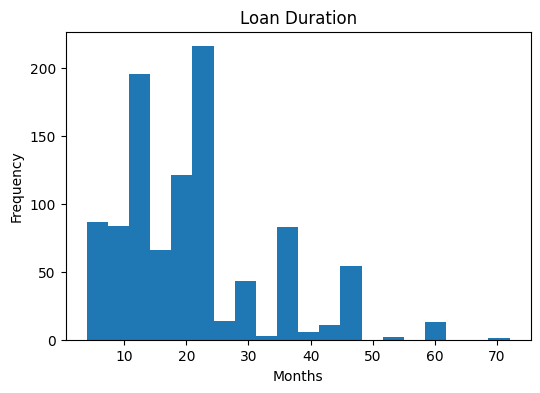

In [20]:
plt.figure(figsize=(6,4))

plt.hist(df["Duration"], bins=20)

plt.title("Loan Duration")
plt.xlabel("Months")
plt.ylabel("Frequency")

plt.show()

In [21]:
df.dtypes

,0
Checking_Account,object
Duration,int64
Credit_History,object
Purpose,object
Credit_Amount,int64
Savings_Account,object
Employment,object
Installment_Rate,int64
Personal_Status_Sex,object
Other_Debtors,object


#Data Preprocessing
separate numerical and categorical columns

In [22]:
categorical_cols = df.select_dtypes(include="object").columns

numerical_cols = df.select_dtypes(exclude="object").columns

print(categorical_cols)

print(numerical_cols)

Index(['Checking_Account', 'Credit_History', 'Purpose', 'Savings_Account',
       'Employment', 'Personal_Status_Sex', 'Other_Debtors', 'Property',
       'Other_Installment_Plans', 'Housing', 'Job', 'Telephone',
       'Foreign_Worker'],
      dtype='object')
Index(['Duration', 'Credit_Amount', 'Installment_Rate', 'Residence_Since',
       'Age', 'Existing_Credits', 'Dependents', 'Risk'],
      dtype='object')


In [23]:
#Encode categorical Features
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [24]:
#check encoded dataset
df.head()

,Checking_Account,Duration,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Dependents,Telephone,Foreign_Worker,Risk
0,0,6,4,4,1169,4,4,4,2,0,...,0,67,2,1,2,2,1,1,0,1
1,1,48,2,4,5951,0,2,2,1,0,...,0,22,2,1,1,2,1,0,0,2
2,3,12,4,7,2096,0,3,2,2,0,...,0,49,2,1,1,1,2,0,0,1
3,0,42,2,3,7882,0,3,2,2,2,...,1,45,2,2,1,2,2,0,0,1
4,0,24,3,0,4870,0,2,3,2,0,...,3,53,2,2,2,2,2,0,0,2


In [25]:
#convert target variable
df["Risk"] = df["Risk"].map({1:1, 2:0})

In [26]:
df["Risk"].value_counts()

,count
Risk,
1,700
0,300


In [27]:
#split features and target
X = df.drop("Risk", axis=1)

y = df["Risk"]

In [28]:
print(X.shape)
print(y.shape)

(1000, 20)
(1000,)


# Train-Test Split

The dataset is divided into training and testing sets.

- Training Data: 80%
- Testing Data: 20%

This allows the model to learn from one portion of the data and evaluate its performance on unseen data.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print(X_train.shape)
print(X_test.shape)

(800, 20)
(200, 20)


# Feature Scaling

Feature Scaling standardizes numerical values so that features with larger ranges do not dominate the learning process.

StandardScaler is used to transform the training and testing data.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Logistic Regression

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems.

It serves as the baseline model for this project.

In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [33]:
#Evalaute Logistic Regression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Accuracy : 0.74
Precision: 0.8013698630136986
Recall   : 0.8357142857142857
F1 Score : 0.8181818181818182


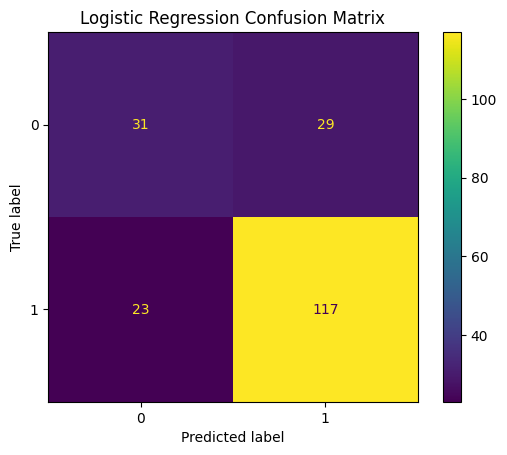

In [34]:
#Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [35]:
#Roc-AUC score
from sklearn.metrics import roc_auc_score

prob = lr.predict_proba(X_test_scaled)[:,1]

print("ROC-AUC Score :", roc_auc_score(y_test, prob))

ROC-AUC Score : 0.7822619047619048


# Decision Tree Classifier

Decision Trees classify data by learning a sequence of decision rules from the training dataset.

They are easy to interpret and can capture non-linear relationships.

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Results")
print("----------------------")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

dt_prob = dt.predict_proba(X_test)[:,1]

print("ROC-AUC  :", roc_auc_score(y_test, dt_prob))

Decision Tree Results
----------------------
Accuracy : 0.725
Precision: 0.8695652173913043
Recall   : 0.7142857142857143
F1 Score : 0.7843137254901961
ROC-AUC  : 0.7568452380952381


# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

This model generally performs well on structured tabular datasets.

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Results")
print("----------------------")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

rf_prob = rf.predict_proba(X_test)[:,1]

print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Random Forest Results
----------------------
Accuracy : 0.785
Precision: 0.8089171974522293
Recall   : 0.9071428571428571
F1 Score : 0.8552188552188552
ROC-AUC  : 0.8180357142857144


# Model Comparison

The performance of all trained machine learning models is compared using the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

The best-performing model is selected based on these metrics.

In [38]:
#Compare All 3 models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.785,0.808917,0.907143,0.855219,0.818036
0,Logistic Regression,0.740,0.801370,0.835714,0.818182,0.782262
1,Decision Tree,0.725,0.869565,0.714286,0.784314,0.756845


# Feature Importance

Feature Importance identifies which features contribute the most to predicting customer creditworthiness.

This helps in understanding the factors influencing the model's predictions.

In [39]:
#Feature Importance
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Credit_Amount,0.133653
0,Checking_Account,0.109497
1,Duration,0.105940
12,Age,0.101644
3,Purpose,0.067059
2,Credit_History,0.053089
6,Employment,0.052203
11,Property,0.046704
5,Savings_Account,0.044318
10,Residence_Since,0.040892


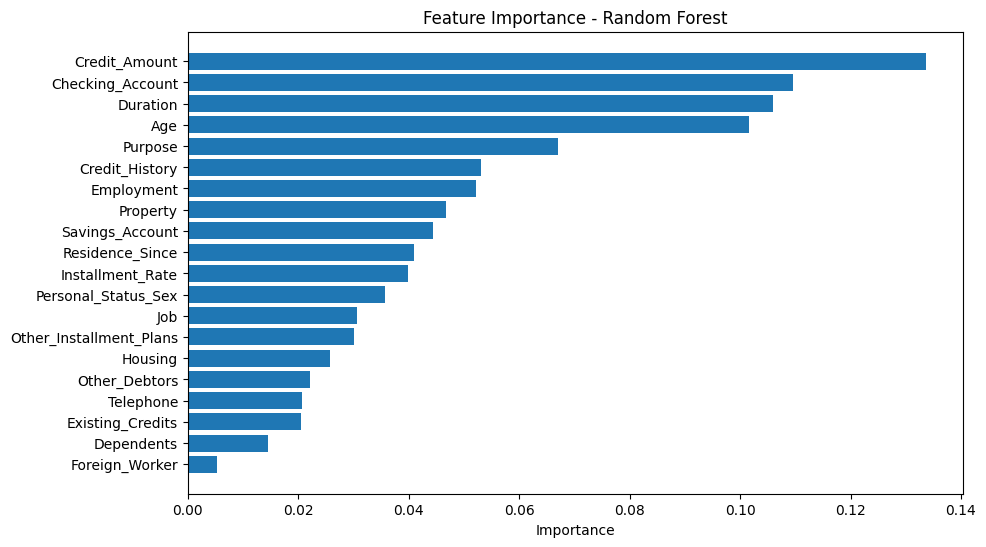

In [40]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [41]:
#save the best model
import joblib

joblib.dump(rf, "best_model.pkl")

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

#  Confusion Matrix

The Confusion Matrix provides a detailed summary of correct and incorrect predictions made by the model.

It helps evaluate classification performance beyond overall accuracy.

In [42]:
from sklearn.metrics import classification_report

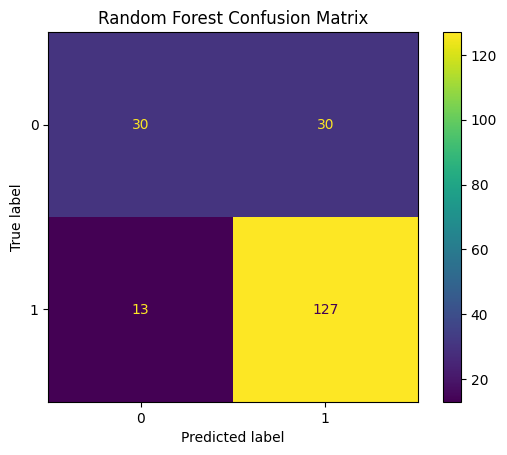

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)

plt.title("Random Forest Confusion Matrix")

plt.show()

# Classification Report

The Classification Report summarizes the model's performance using Precision, Recall, F1-Score, and Support for each class.

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.70      0.50      0.58        60
           1       0.81      0.91      0.86       140

    accuracy                           0.79       200
   macro avg       0.75      0.70      0.72       200
weighted avg       0.78      0.79      0.77       200



# ROC Curve

The Receiver Operating Characteristic (ROC) Curve illustrates the model's ability to distinguish between positive and negative classes.

A higher Area Under the Curve (ROC-AUC) indicates better classification performance.

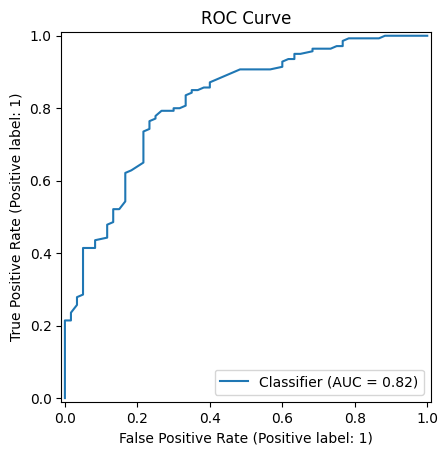

In [45]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, rf_prob)

plt.title("ROC Curve")

plt.show()

# Save the Best Model

The best-performing model (Random Forest) is saved using Joblib for future predictions without retraining.

In [46]:
#save the best model
import joblib

joblib.dump(rf, "best_model.pkl")

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Conclusion

In this project, three machine learning classification algorithms were implemented and evaluated for credit risk prediction:

- Logistic Regression
- Decision Tree
- Random Forest

Among the three models, **Random Forest** achieved the highest overall performance.

### Final Model Performance

- **Accuracy:** 78.5%
- **Precision:** 80.89%
- **Recall:** 90.71%
- **F1-Score:** 85.52%
- **ROC-AUC Score:** 81.80%

Based on these results, Random Forest was selected as the final model for predicting customer creditworthiness.

#  Future Improvements

This project can be further enhanced by:

- Applying Hyperparameter Tuning using GridSearchCV or RandomizedSearchCV.
- Experimenting with advanced ensemble algorithms such as XGBoost, LightGBM, or CatBoost.
- Deploying the model using Streamlit or Flask.
- Training on larger real-world financial datasets.
- Performing feature engineering to improve prediction performance.